In [2]:
from common import *

# Addition
[Optimal Toffoli-Depth Quantum Adder](https://arxiv.org/html/2405.02523v1#S5)

> After comparing all the proposed designs, we confirm that the Quantum Slansky + Strategy 2 is the optimal depth design choice in this work. This is attributed to its minimal Toffoli-Depth and fewer CNOT operations involved, especially considering that Slansky only requires P-CNOT operations during CNOT operations, without the need for G-CNOT operations.

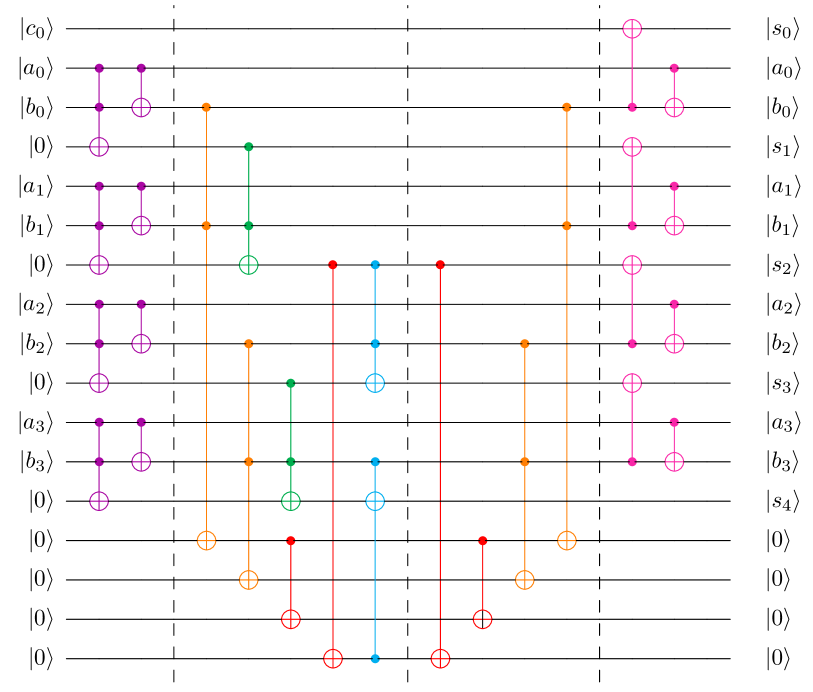

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector

a = QuantumRegister(4, "A")
b = QuantumRegister(4, "B")
s = QuantumRegister(5, "sum")  # First bit is also the carry-in
ancillas = QuantumRegister(4, "ancillas")  # for some strange reason AncillaRegister is broken???
sum_creg = ClassicalRegister(5, "result")

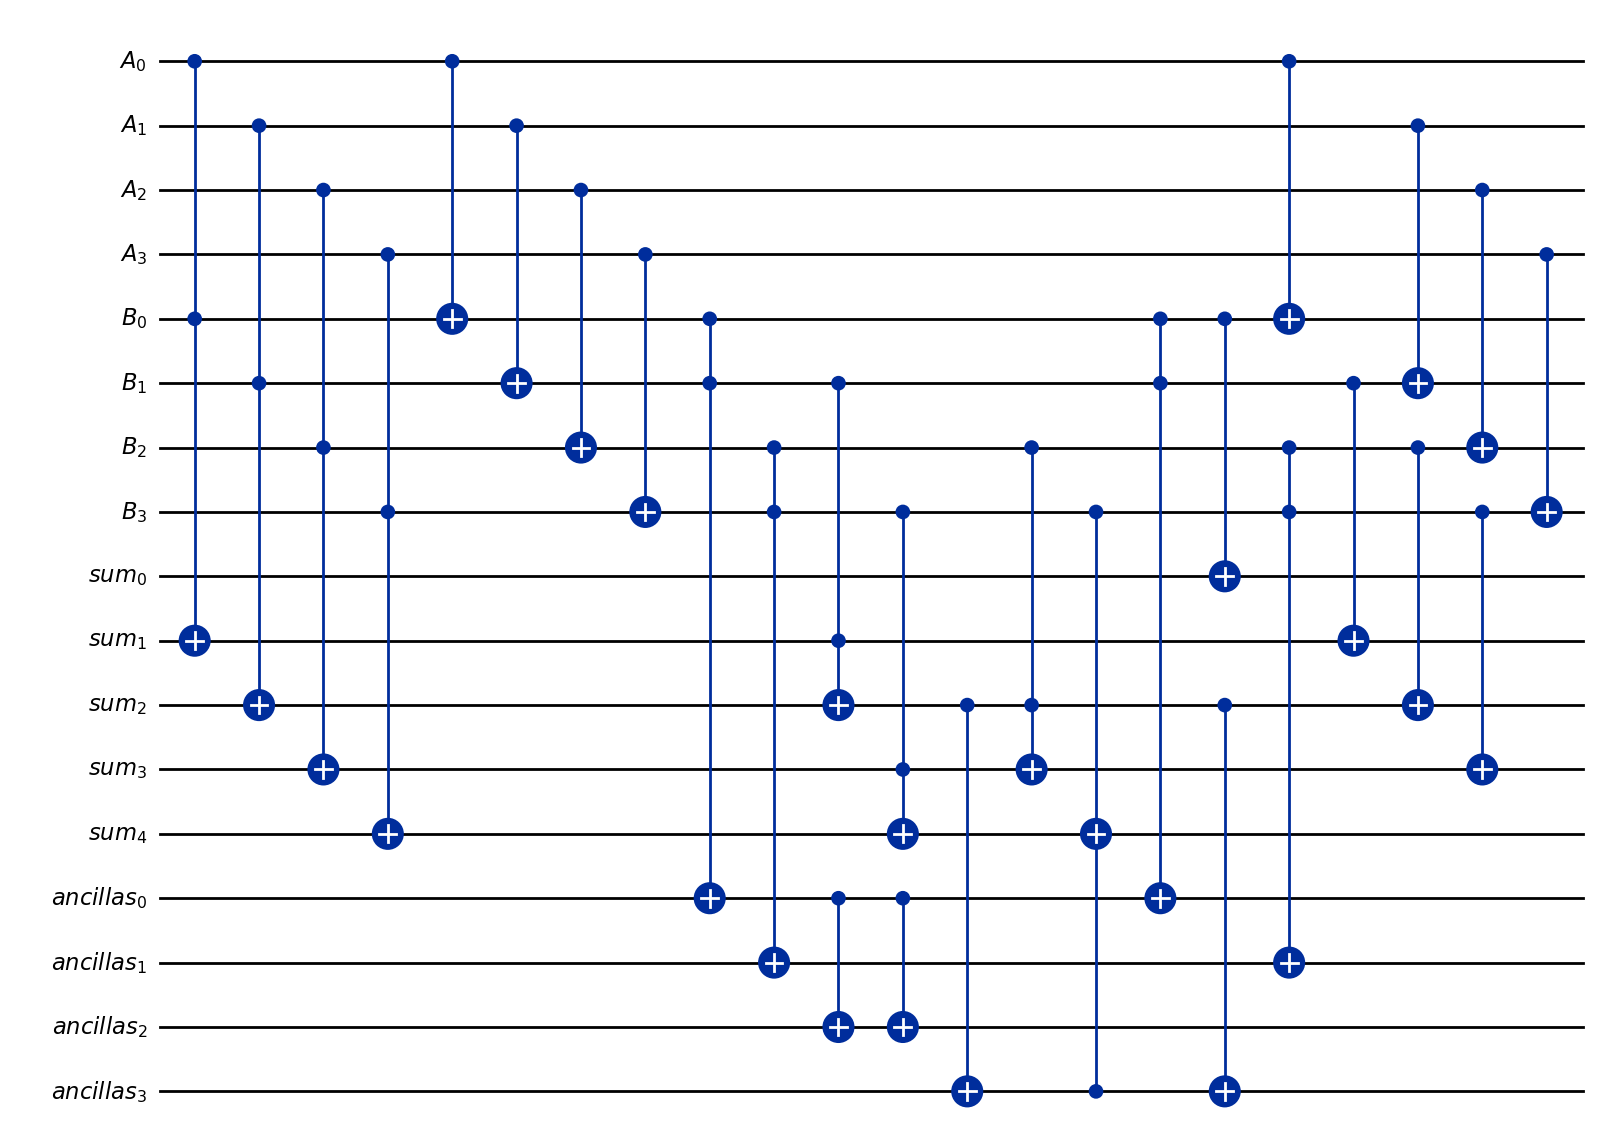

In [4]:
# Slansky
add_qc = QuantumCircuit(a, b, s, ancillas)
# add_qc.add_register(sum_creg)

def append_adder_circuit(qc: QuantumCircuit, a: QuantumRegister, b: QuantumRegister, s: QuantumRegister, ancillas: QuantumRegister):
    # Step 1
    # Calculation of initial propagation and generation
    for i in range(4):
        qc.ccx(a[i], b[i], s[i+1])
        qc.cx(a[i], b[i])

    # Step 2
    # 1st propagation
    qc.ccx(b[0], b[1], ancillas[0])
    qc.ccx(b[2], b[3], ancillas[1])

    # 1st generation
    qc.ccx(s[1], b[1], s[2])
    qc.ccx(s[3], b[3], s[4])

    # Copy
    qc.cx(ancillas[0], ancillas[2])
    qc.cx(s[2], ancillas[3])

    # 2nd generation
    qc.ccx(s[2], b[2], s[3])
    qc.ccx(ancillas[3], b[3], s[4])

    # Step 3
    # Copy
    qc.cx(s[2], ancillas[3])
    qc.cx(ancillas[0], ancillas[2])

    # Propagation uncomputation
    qc.ccx(b[2], b[3], ancillas[1])
    qc.ccx(b[0], b[1], ancillas[0])
        
    # Step 4
    for i in range(4):
        qc.cx(b[i], s[i])
        qc.cx(a[i], b[i])
    
append_adder_circuit(add_qc, a, b, s, ancillas)
add_qc.draw(output="mpl")

## Test

In [4]:
state = Statevector.from_instruction(add_qc)
result = str(list(state.probabilities_dict().keys())[0]) # Simulation is exact
print(f"Result: {result}")

Result: 00000000000000000


In [5]:
len(a) + len(b) + len(s) + len(ancillas)

17

In [ ]:
# We'll apply gates up to, but not including, the measurement
qc = QuantumCircuit(a, b, s, ancillas)
qc.reset(range(len(qc.qubits)))
qc.x(a[0])
qc.x(b[0])
qc.x(b[1])
qc.x(b[3])
append_adder_circuit(qc, a, b, s, ancillas)
debug_circuit(qc)

Applying instruction: CircuitInstruction(operation=Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "A"), index=0>,), clbits=())
State after reset: Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
Probabilities: {'00001110010110000': 1.0}

Applying instruction: CircuitInstruction(operation=Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "A"), index=1>,), clbits=())
State after reset: Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
Probabilities: {'00001110010110000': 1.0}

Applying instruction: CircuitInstruction(operation=Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "A"), index=2>,), clbits=())
State after reset: Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+

In [7]:
test_circuit(add_qc, list(range(16)), a, list(range(16)), b, [a, b, s, ancillas],
             lambda a_val, b_val: (a_val + b_val) % 32, (4, 9))

Initial state: 00000000000000000
Final state:   00000000000000000
Initial state: 00000000000010000
Final state:   00000000100010000
Initial state: 00000000000100000
Final state:   00000001000100000
Initial state: 00000000000110000
Final state:   00000001100110000
Initial state: 00000000001000000
Final state:   00000010001000000
Initial state: 00000000001010000
Final state:   00000010101010000
Initial state: 00000000001100000
Final state:   00000011001100000
Initial state: 00000000001110000
Final state:   00000011101110000
Initial state: 00000000010000000
Final state:   00000100010000000
Initial state: 00000000010010000
Final state:   00000100110010000
Initial state: 00000000010100000
Final state:   00000101010100000
Initial state: 00000000010110000
Final state:   00000101110110000
Initial state: 00000000011000000
Final state:   00000110011000000
Initial state: 00000000011010000
Final state:   00000110111010000
Initial state: 00000000011100000
Final state:   00000111011100000
Initial st

In [ ]:
# Also test with carry-in
adder_with_carry_qc = QuantumCircuit(a, b, s, ancillas)
# Set carry-in to 1
adder_with_carry_qc.x(s[0])
append_adder_circuit(adder_with_carry_qc, a, b, s, ancillas)

test_circuit(adder_with_carry_qc, list(range(16)), a, list(range(16)), b, [a, b, s, ancillas],
             lambda a_val, b_val: (a_val + b_val + 1) % 32, (4, 9))

Initial state: 00000000000000000
Final state:   00000000100000000
Initial state: 00000000000010000
Final state:   00000000000010000
Error: 0, 1: got 0, expected 2
Initial state: 00000000000100000
Final state:   00000001100100000
Initial state: 00000000000110000
Final state:   00000001000110000
Error: 0, 3: got 2, expected 4
Initial state: 00000000001000000
Final state:   00000010101000000
Initial state: 00000000001010000
Final state:   00000010001010000
Error: 0, 5: got 4, expected 6
Initial state: 00000000001100000
Final state:   00000011101100000
Initial state: 00000000001110000
Final state:   00000011001110000
Error: 0, 7: got 6, expected 8
Initial state: 00000000010000000
Final state:   00000100110000000
Initial state: 00000000010010000
Final state:   00000100010010000
Error: 0, 9: got 8, expected 10
Initial state: 00000000010100000
Final state:   00000101110100000
Initial state: 00000000010110000
Final state:   00000101010110000
Error: 0, 11: got 10, expected 12
Initial state: 000

In [17]:
bin(get_answer(add_qc, 0b1111, a, 0b1, b, (a, b, s, ancillas), add_qc.qubits, [(4, 9)])[0])

Initial state: 00000000000011111
Final state:   00001000000011111


'0b10000'

In [11]:
# Test cuccaro adder
from qiskit.synthesis import adder_ripple_c04
c_in = QuantumRegister(1, "c in")
c_out = QuantumRegister(1, "c out")
add_qisk = QuantumCircuit(c_in, a, b, c_out)
add_qisk.append(adder_ripple_c04(4, kind="full"), range(10))
test_circuit(add_qisk, list(range(16)), a, list(range(16)), b, [c_in, a, b, c_out],
             lambda a_val, b_val: (a_val + b_val) % 32, (0, 5))

Initial state: 0000000000
Final state:   0000000000
Initial state: 0000100000
Final state:   0000100000
Initial state: 0001000000
Final state:   0001000000
Initial state: 0001100000
Final state:   0001100000
Initial state: 0010000000
Final state:   0010000000
Initial state: 0010100000
Final state:   0010100000
Initial state: 0011000000
Final state:   0011000000
Initial state: 0011100000
Final state:   0011100000
Initial state: 0100000000
Final state:   0100000000
Initial state: 0100100000
Final state:   0100100000
Initial state: 0101000000
Final state:   0101000000
Initial state: 0101100000
Final state:   0101100000
Initial state: 0110000000
Final state:   0110000000
Initial state: 0110100000
Final state:   0110100000
Initial state: 0111000000
Final state:   0111000000
Initial state: 0111100000
Final state:   0111100000
Initial state: 0000000010
Final state:   0000100010
Initial state: 0000100010
Final state:   0001000010
Initial state: 0001000010
Final state:   0001100010
Initial stat

In [12]:
# With carry-in
add_qisk_with_carry = QuantumCircuit(c_in, a, b, c_out)
add_qisk_with_carry.x(c_in[0])
add_qisk_with_carry.append(adder_ripple_c04(4, kind="full"), range(10))
test_circuit(add_qisk_with_carry, list(range(16)), a, list(range(16)), b, [c_in, a, b, c_out],
             lambda a_val, b_val: (a_val + b_val + 1) % 32, (0, 5))

Initial state: 0000000000
Final state:   0000100001
Initial state: 0000100000
Final state:   0001000001
Initial state: 0001000000
Final state:   0001100001
Initial state: 0001100000
Final state:   0010000001
Initial state: 0010000000
Final state:   0010100001
Initial state: 0010100000
Final state:   0011000001
Initial state: 0011000000
Final state:   0011100001
Initial state: 0011100000
Final state:   0100000001
Initial state: 0100000000
Final state:   0100100001
Initial state: 0100100000
Final state:   0101000001
Initial state: 0101000000
Final state:   0101100001
Initial state: 0101100000
Final state:   0110000001
Initial state: 0110000000
Final state:   0110100001
Initial state: 0110100000
Final state:   0111000001
Initial state: 0111000000
Final state:   0111100001
Initial state: 0111100000
Final state:   1000000001
Initial state: 0000000010
Final state:   0001000011
Initial state: 0000100010
Final state:   0001100011
Initial state: 0001000010
Final state:   0010000011
Initial stat

## Inspect circuit

In [15]:
print_metrics(add_qc)

Size: 28
Toffoli count: 12
CZ count: 198
T count: 84
Depth: 9
Toffoli depth: 5
CZ depth: 86
T depth: 20
Width: 17
Algebraic connectivity: 0.2620124763082069


## Run in IBM Quantum

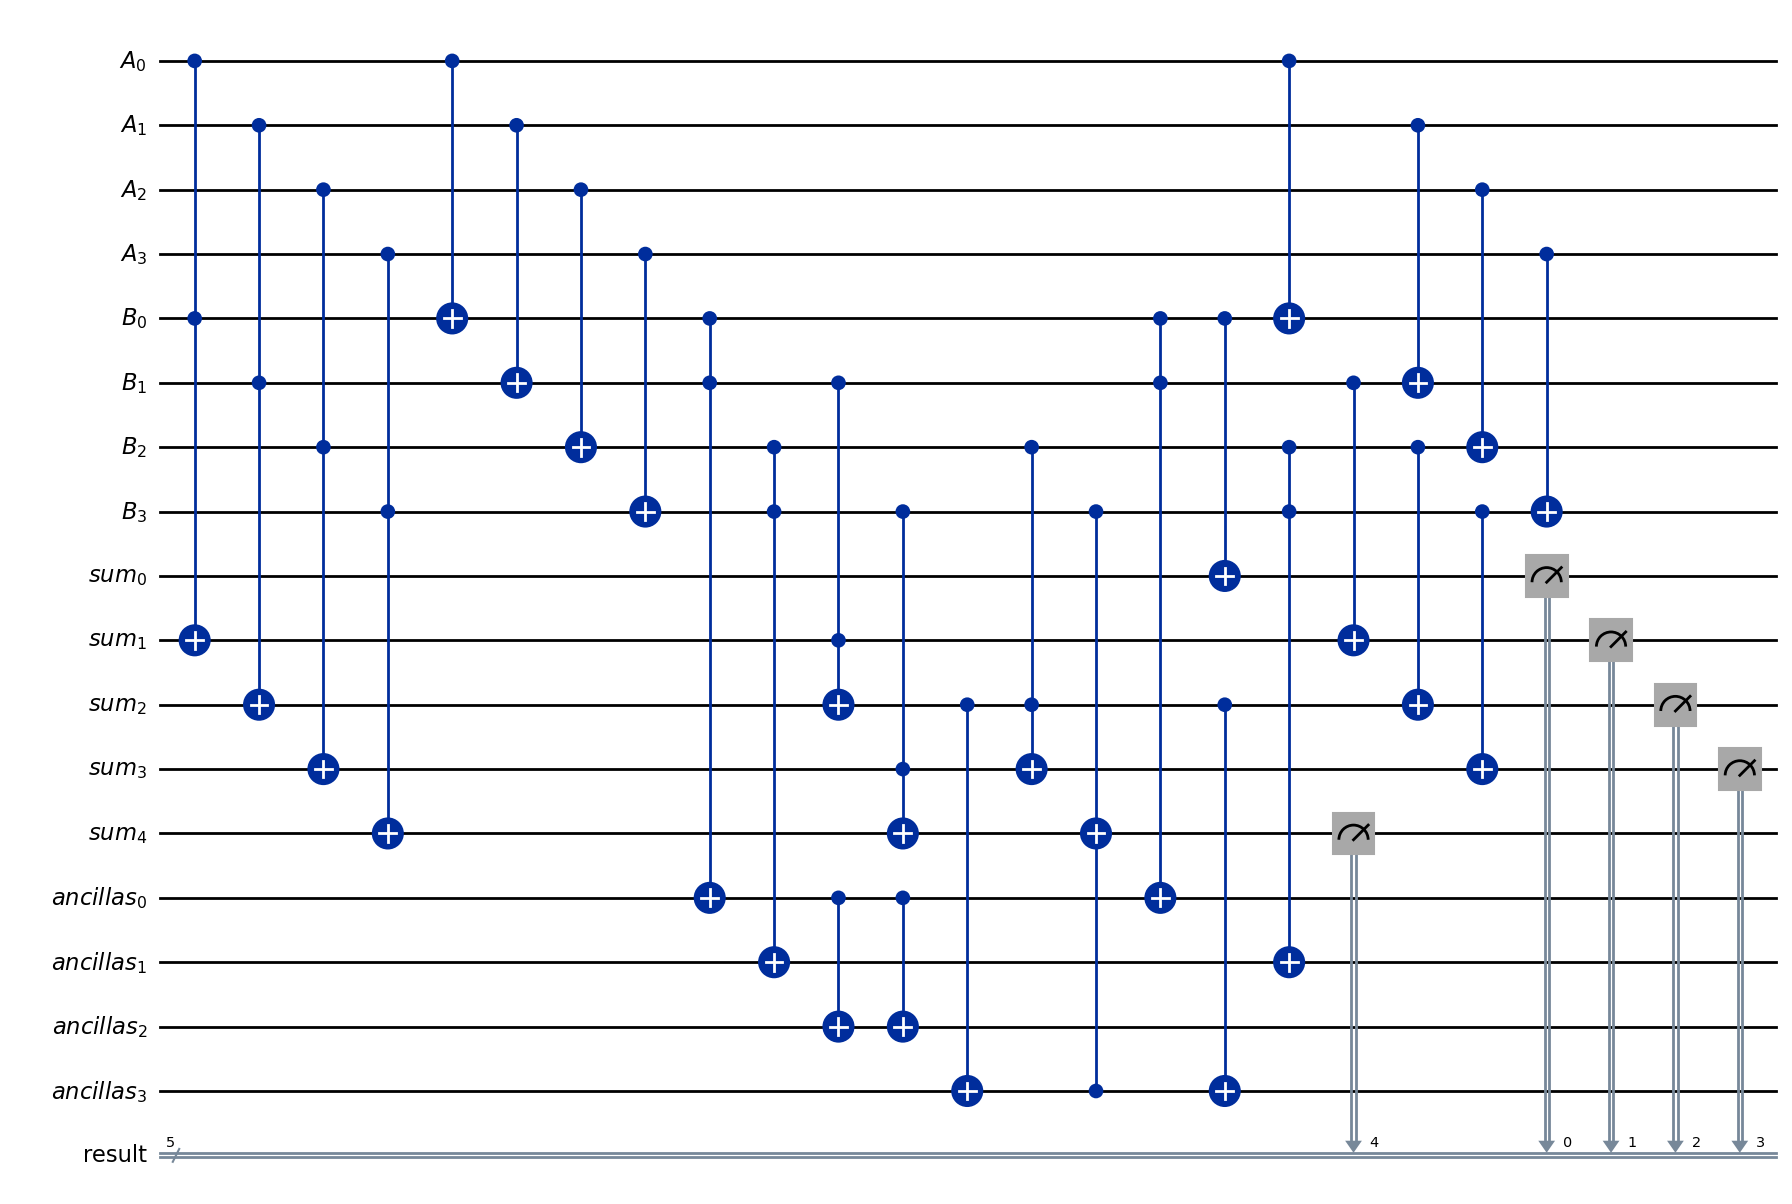

In [ ]:
# Measure sum qubits
add_qc.add_register(sum_creg)
add_qc.measure(s, sum_creg)
add_qc.draw(output="mpl")

In [16]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

sv_sampler = StatevectorSampler()
job = sv_sampler.run([add_qc])
result = job.result()[0]
result.data.result.get_counts()

{'00011': 1024}

In [51]:
test_add_qc = QuantumCircuit(a, b, s, ancillas, sum_creg)
test_add_qc.x(a[0])
test_add_qc.x(a[1])
test_add_qc.x(b[0])
test_add_qc.x(b[1])
test_add_qc.x(b[2])
test_add_qc.append(add_qc, test_add_qc.qubits, sum_creg)
isa_circuit_add = pm.run(add_qc)
# isa_circuit_add.draw(output="mpl", idle_wires=False)

In [52]:
from qiskit_ibm_runtime import SamplerV2
backend_sampler = SamplerV2(mode=backend)
backend_sampler.options.default_shots = 2**11
job = backend_sampler.run([isa_circuit_add])
print(f">>> Job ID: {job.job_id()}")

/Users/danielcolon/Developer/school/Venkat/qiskit/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1210: UserWarning: This instance has met its usage limit. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2F8cb7f892c343444abd2816bf720e090e%3Abefd760e-5d60-4288-8f7f-d2c7af7d7238%3A%3A for more details.
  warnings.warn(


>>> Job ID: d7hcea493s0c738sm1d0


In [4]:
job = service.job("d7chcf3klj2c73f0ik80")

IBMInputValueError: 'No matching instances found for the following filters: .'

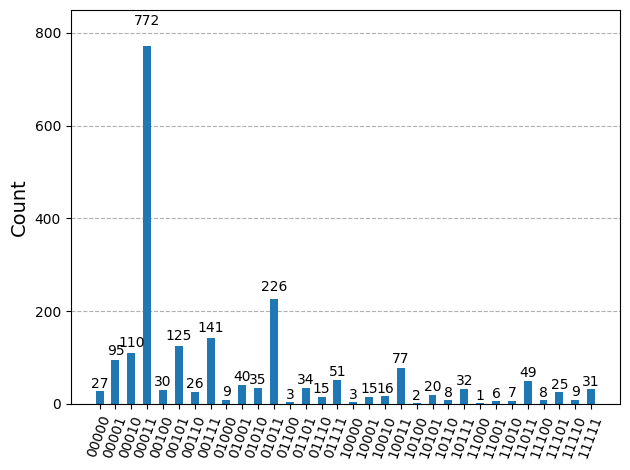

In [66]:
result = job.result()[0]
plot_histogram(result.data.c0.get_counts())

Compare with Qiskit's adder
https://quantum.cloud.ibm.com/docs/en/api/qiskit/synthesis#adder_ripple_c04

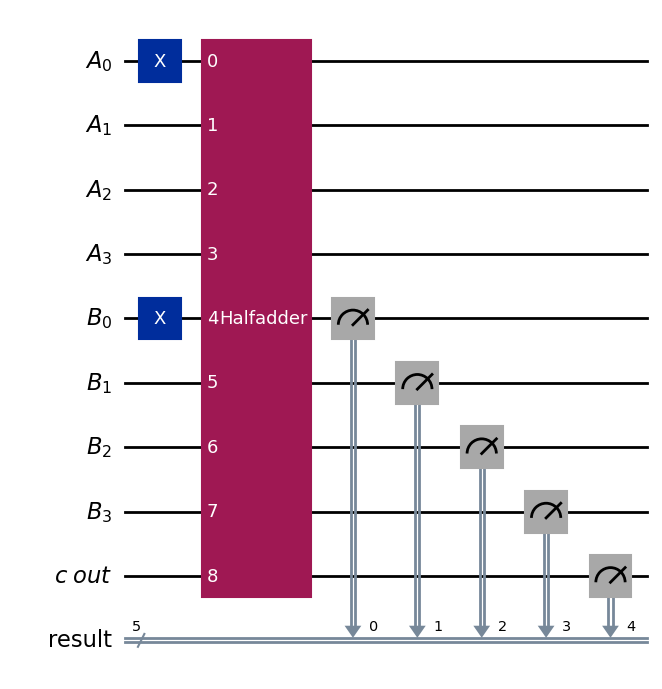

In [ ]:
c_out = QuantumRegister(1, "c out")
add_qisk = QuantumCircuit(a, b, c_out, sum_creg)
add_qisk.x(a[0])
add_qisk.x(b[0])
add_qisk.append(HalfAdderGate(4), range(9))
add_qisk.measure(list(b) + list(c_out), sum_creg)
add_qisk.draw(output="mpl")

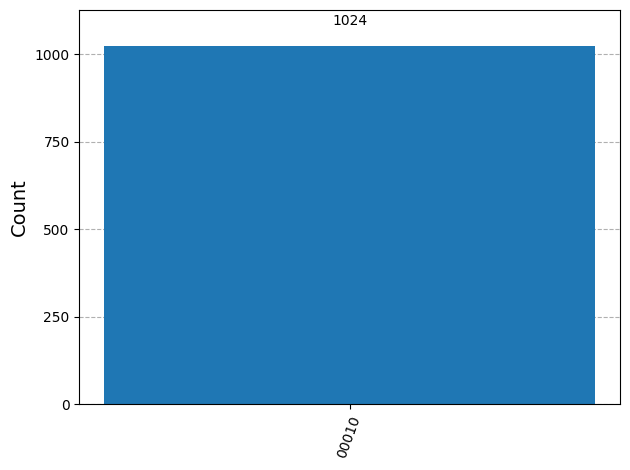

In [6]:
job = sv_sampler.run([add_qisk])
result = job.result()[0]
plot_histogram(result.data.result.get_counts())

In [7]:
isa_circuit_add_qiskit = pm.run(add_qisk)
job = backend_sampler.run([isa_circuit_add_qiskit])
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d7dc78b0g7hs73drp4u0


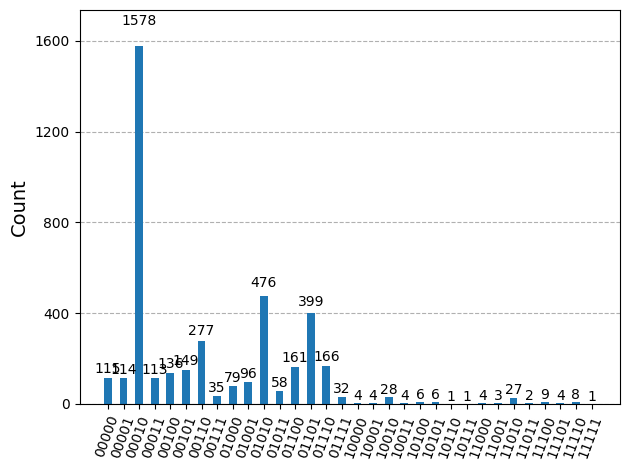

In [8]:
result = job.result()[0]
plot_histogram(result.data.result.get_counts())

Worse than Slansky!

But, it's in place, so we'll use it in the multiplier algorithm.

Future work: modify Slansky adder to be in place (swaps should do it)

# Subtraction
Reusing the addition circuit. Using Method 3; lower gate count, and addition circuit accepts input carry.

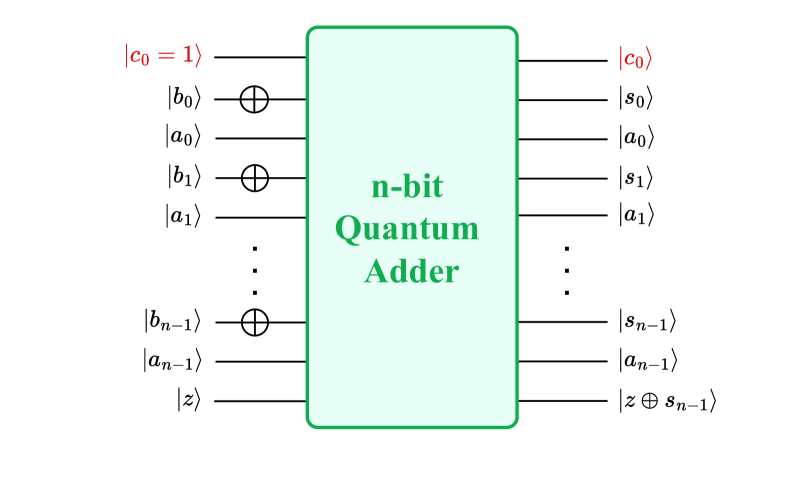

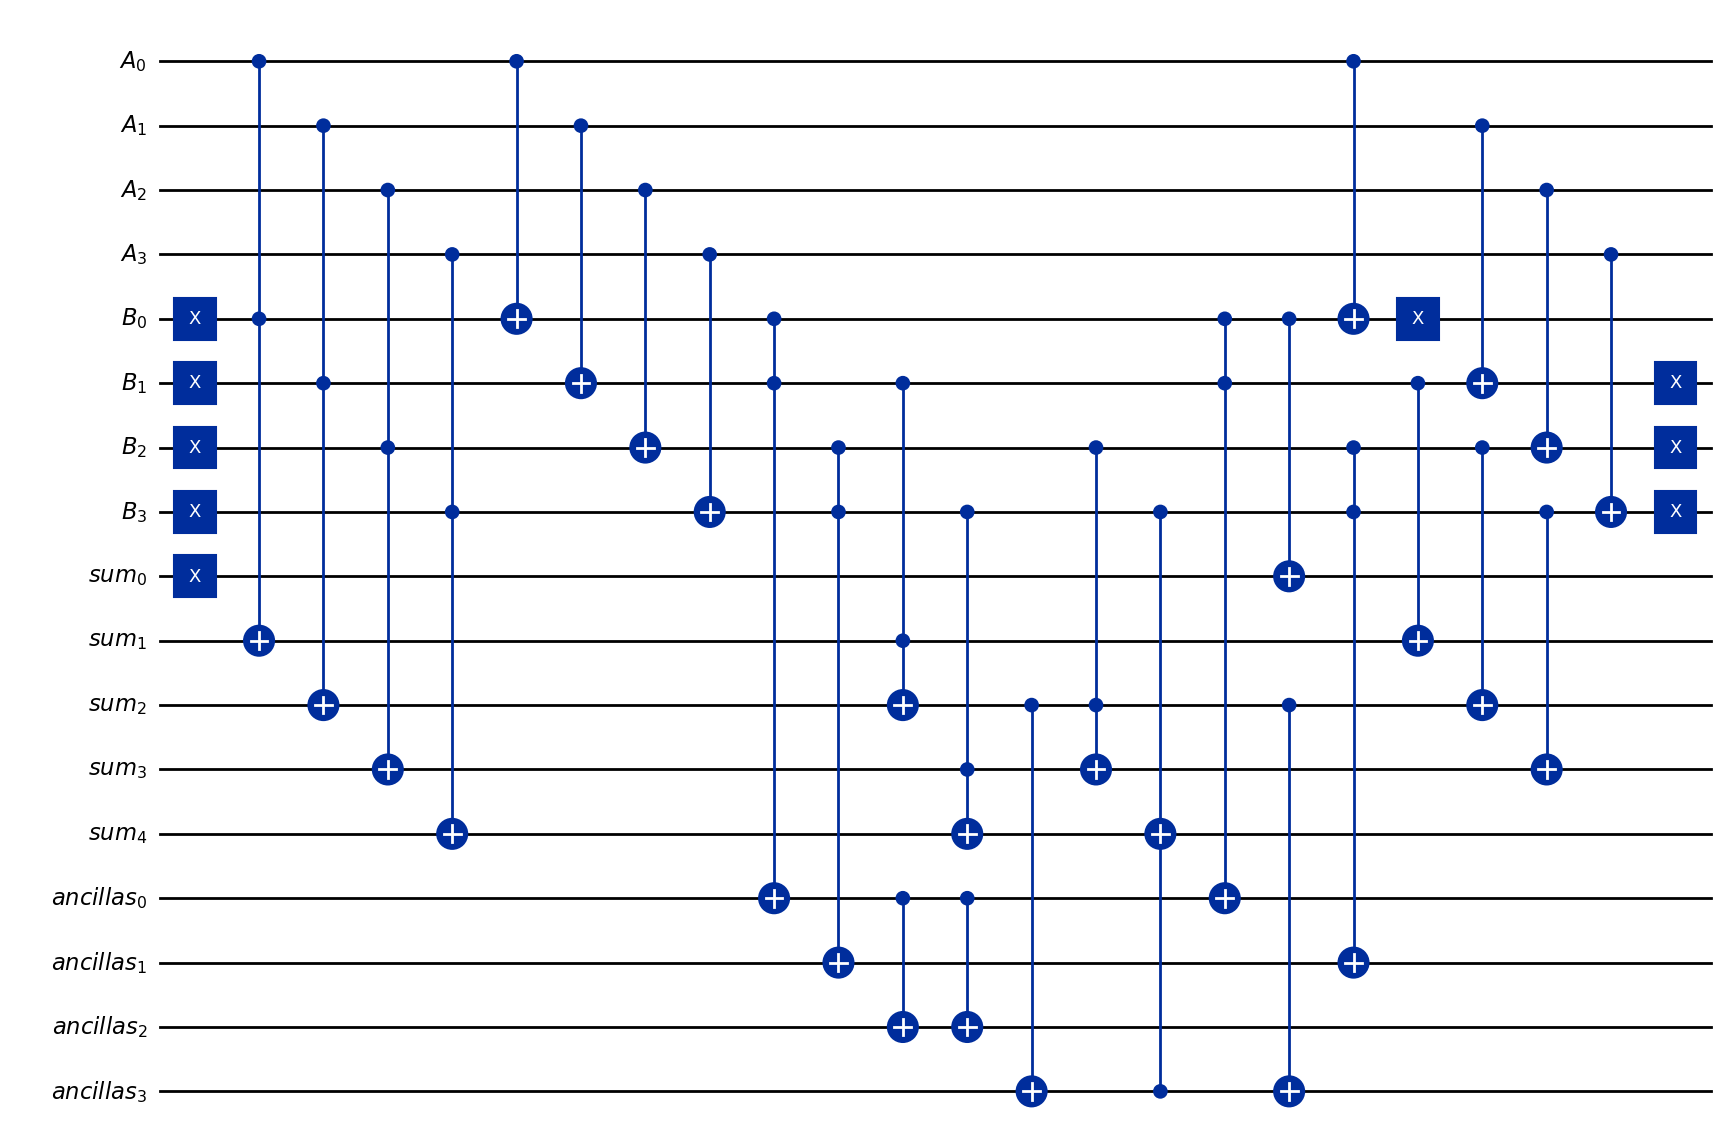

In [11]:
sub_creg = ClassicalRegister(5, "result")
sub_qc = QuantumCircuit(a, b, s, ancillas)

# A - B = A + (2's complement of B) = A + (-B + 1)
def append_subtractor_circuit(qc: QuantumCircuit, a: QuantumRegister, b: QuantumRegister, s: QuantumRegister, ancillas: QuantumRegister):
    # Set carry-in to 1
    qc.x(s[0])
    
    # Complement B
    qc.x(b)
    
    # Perform addition
    append_adder_circuit(qc, a, b, s, ancillas)
    
    # Retrieve B
    qc.x(b)

append_subtractor_circuit(sub_qc, a, b, s, ancillas)
sub_qc.draw(output="mpl")

## Test

In [5]:
state = Statevector.from_instruction(sub_qc)
result = str(list(state.probabilities_dict().keys())[0])
print(f"Result: {result}")

Result: 00000111000000000


In [18]:
# Test subtractor
wrongs = []
count_wrong = 0
count_total = 0
for a_val in range(16):
    for b_val in range(0, a_val + 1):  # Only test cases where a >= b to avoid negative results
        answer = get_answer(sub_qc, a_val, a, b_val, b, (a, b, s, ancillas), sub_qc.qubits, [(4, 8)])[0]
        expected = (a_val - b_val) % 32
        if answer != expected:
            count_wrong += 1
            print(f"Error: {a_val} - {b_val}: got {answer}, expected {expected}")
            wrongs.append((a_val, b_val, answer, expected))
        count_total += 1

print("Total wrongs:", count_wrong)
print("Total tests:", count_total)
print("Total wrongs:", count_wrong)
print("Wrongs:")
for a_val, b_val, answer, expected in wrongs:
    # In binary
    print(f"  {bin(a_val)} - {bin(b_val)}: got {bin(answer)}, expected {bin(expected)}")

Initial state: 00000000000000000
Final state:   00000111000000000
Error: 0 - 0: got 7, expected 0
Initial state: 00000000000000001
Final state:   00001000100000001
Error: 1 - 0: got 8, expected 1
Initial state: 00000000000010001
Final state:   00000111000010001
Error: 1 - 1: got 7, expected 0
Initial state: 00000000000000010
Final state:   00001000000000010
Error: 2 - 0: got 8, expected 2
Initial state: 00000000000010010
Final state:   00001000100010010
Error: 2 - 1: got 8, expected 1
Initial state: 00000000000100010
Final state:   00000111000100010
Error: 2 - 2: got 7, expected 0
Initial state: 00000000000000011
Final state:   00001001100000011
Error: 3 - 0: got 9, expected 3
Initial state: 00000000000010011
Final state:   00001000000010011
Error: 3 - 1: got 8, expected 2
Initial state: 00000000000100011
Final state:   00001000100100011
Error: 3 - 2: got 8, expected 1
Initial state: 00000000000110011
Final state:   00000111000110011
Error: 3 - 3: got 7, expected 0
Initial state: 00000

In [27]:
get_answer(sub_qc, 0b0, a, 0b0, b, (a, b, s, ancillas), sub_qc.qubits, [(5, 9)])[0]

Initial state: 00000000000000000
Final state:   00000111000000000


14

In [30]:
def _get_answer(circuit, a_val, a_reg, b_val, b_reg, all_regs, qubits, answer_ranges):
    qc = QuantumCircuit(*all_regs)
    for i in range(4):
        if (a_val >> i) & 1:
            qc.x(a_reg[i])
        if (b_val >> i) & 1:
            qc.x(b_reg[i])
    qc.x(s[0])  # Set carry-in to 1 for subtraction
    print(f"Initial state: {extract_state(qc)}")
    qc.append(circuit, qubits)
    bitstr = extract_state(qc)
    print(f"Final state:   {bitstr}")
    return tuple(int(bitstr[a_range[0]:a_range[1]], 2) for a_range in answer_ranges)

_get_answer(add_qc, 0b0, a, 0b1111, b, (a, b, s, ancillas), add_qc.qubits, [(5, 9)])[0]

Initial state: 00000000111110000
Final state:   00000111011110000


14

## Inspect

Size: 37
Toffoli count: 12
CZ count: 201
T count: 84
Depth: 11
Toffoli depth: 5
CZ depth: 81
T depth: 20
Width: 17
Algebraic connectivity: 0.2620124763082066


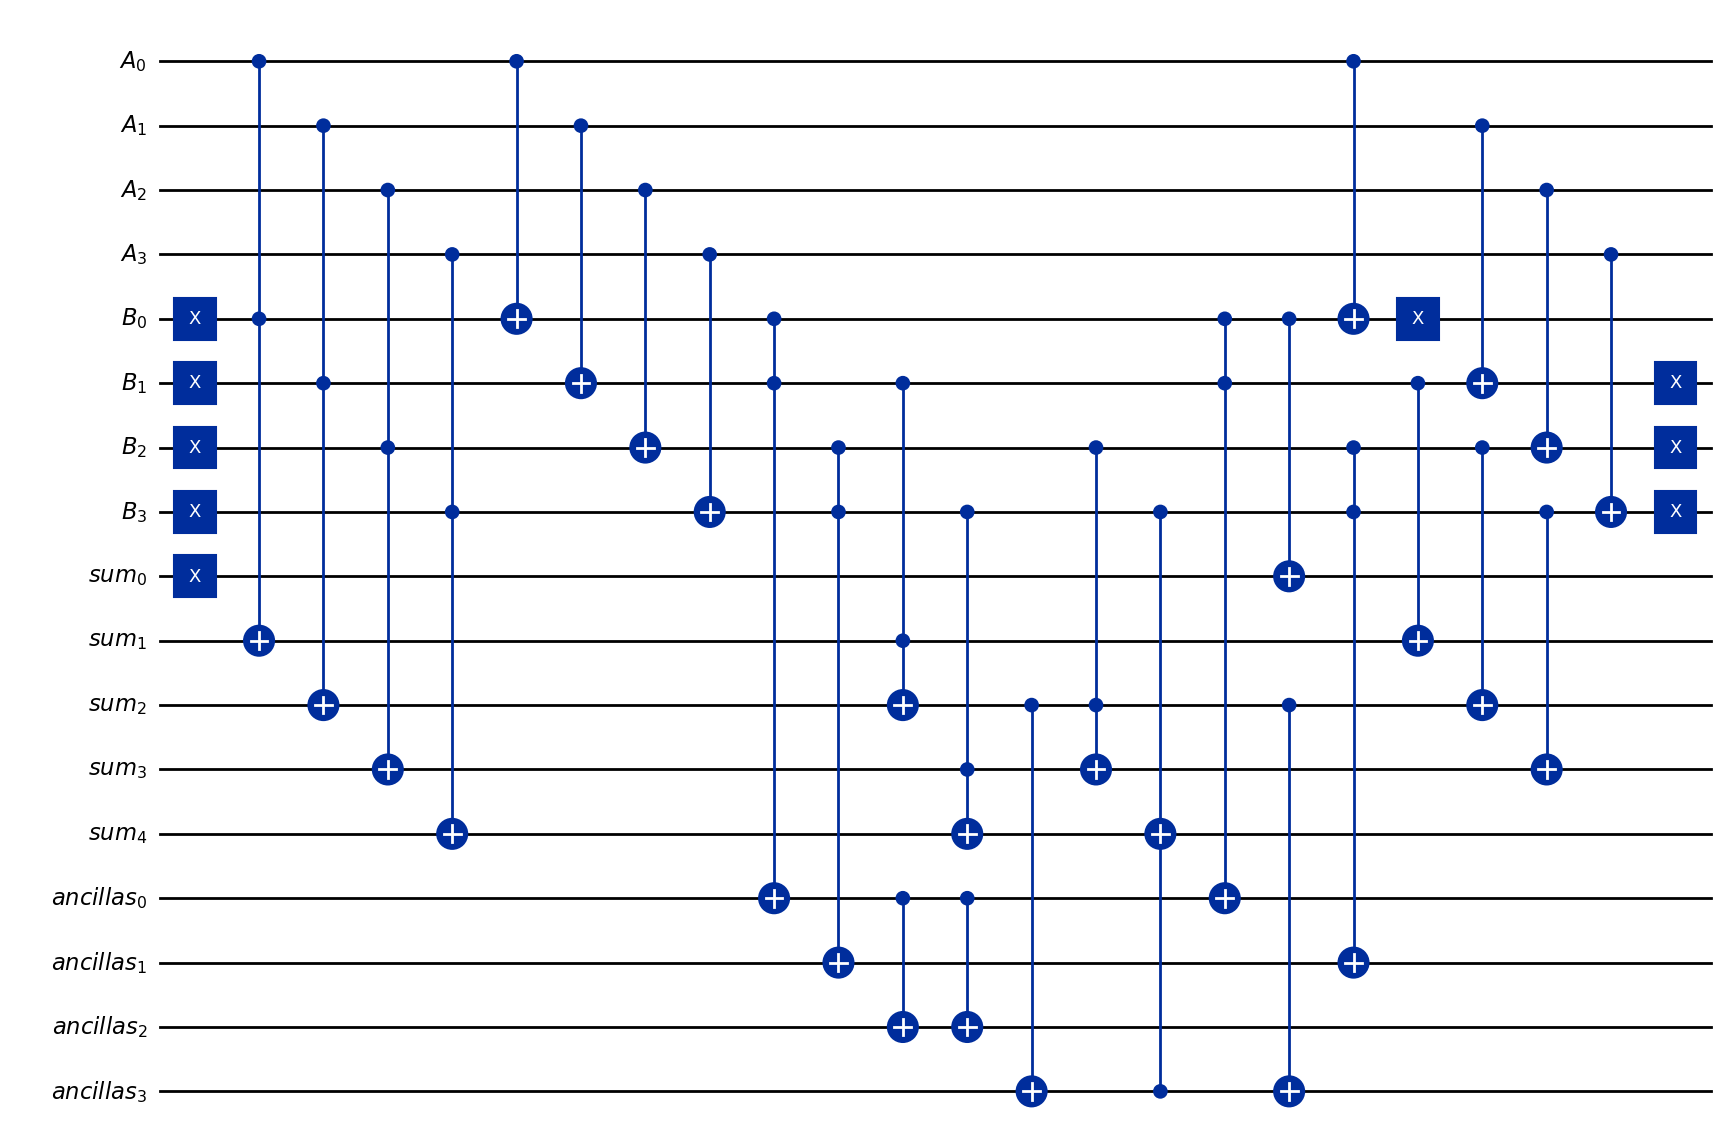

In [17]:
print_metrics(sub_qc)
sub_qc.draw(output="mpl")

## Run

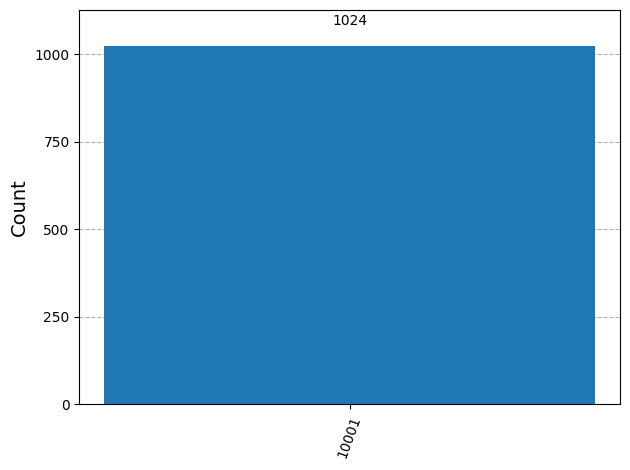

In [ ]:
sub_qc.add_register(sub_creg)
sub_qc.measure(s, sub_creg)
job = sv_sampler.run([sub_qc])
result = job.result()[0]
plot_histogram(result.data['result'].get_counts())

# Last bit should be ignored

In [ ]:
# Run on IBM Quantum
isa_circuit_sub = pm.run(sub_qc)
job = backend_sampler.run([isa_circuit_sub])
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d7cmfajklj2c73f0onc0


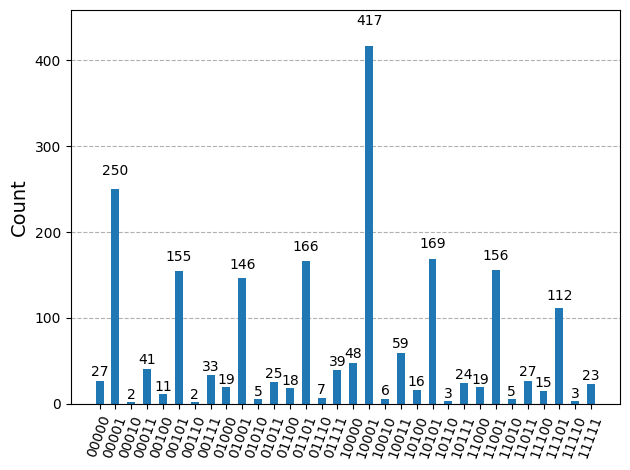

In [ ]:
result = job.result()[0]
plot_histogram(result.data['result'].get_counts())